In [1]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/xgboost.pkl")

In [3]:
X_test = pd.read_csv("../data/test/X_test.csv")

In [5]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(model)

In [6]:
# Calculate SHAP Values
shap_values = explainer.shap_values(X_test)

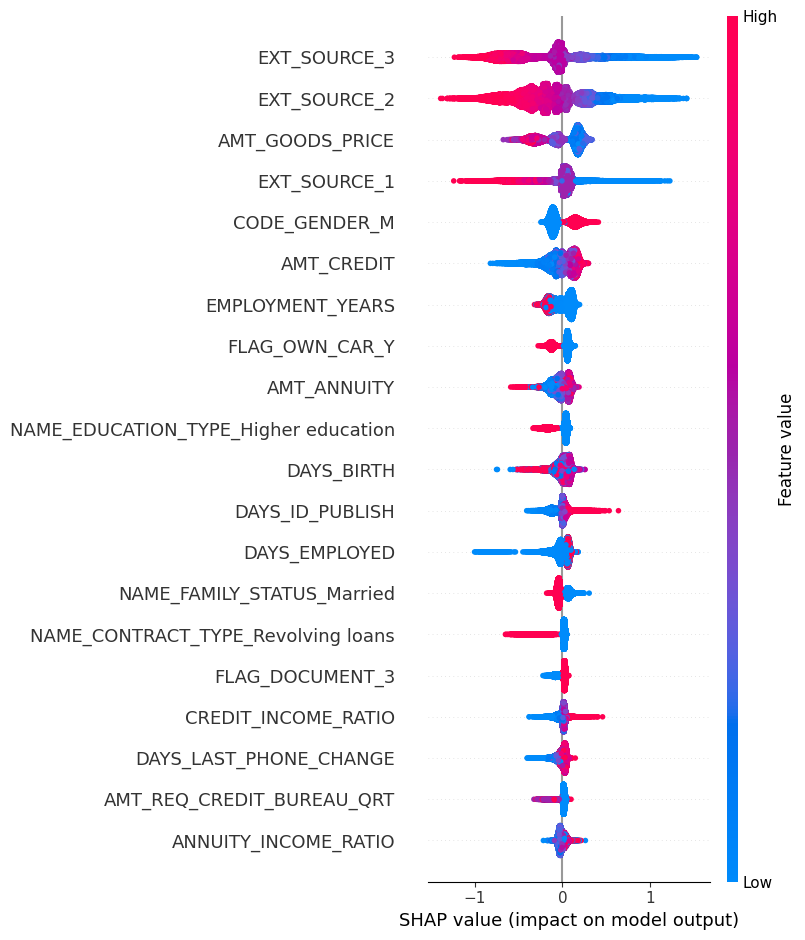

In [8]:
# Global Feature Importance : Which features influence predictions the most across all customers.
shap.summary_plot(shap_values,X_test)

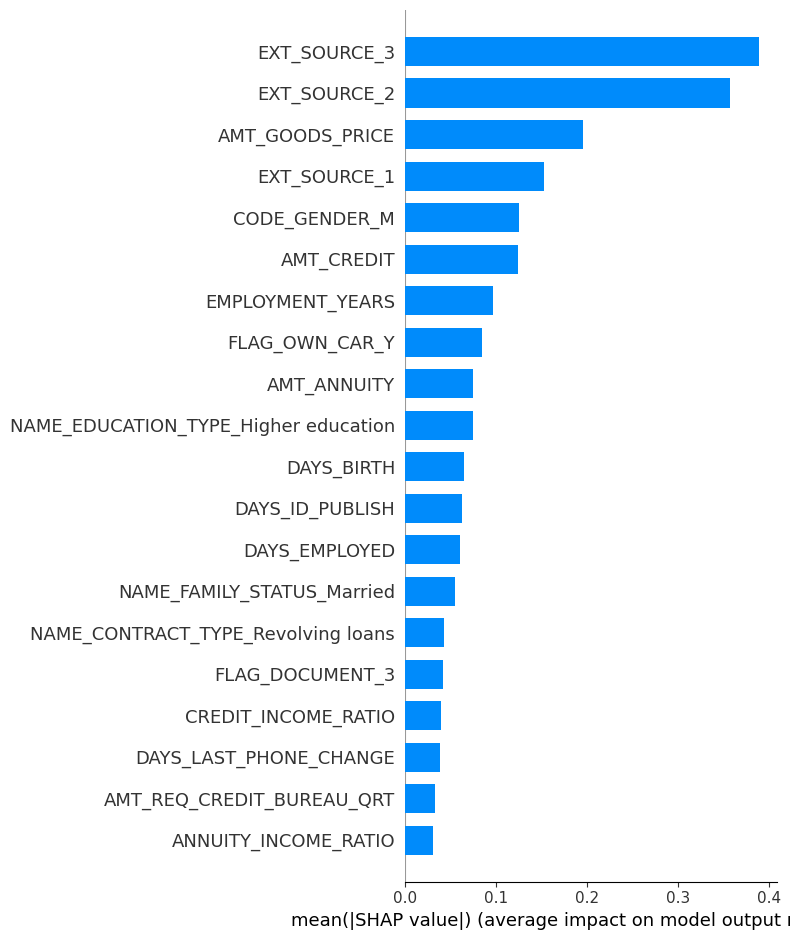

In [9]:
shap.summary_plot(shap_values,X_test,plot_type="bar")

In [10]:
# Explain One Customer
customer = 0

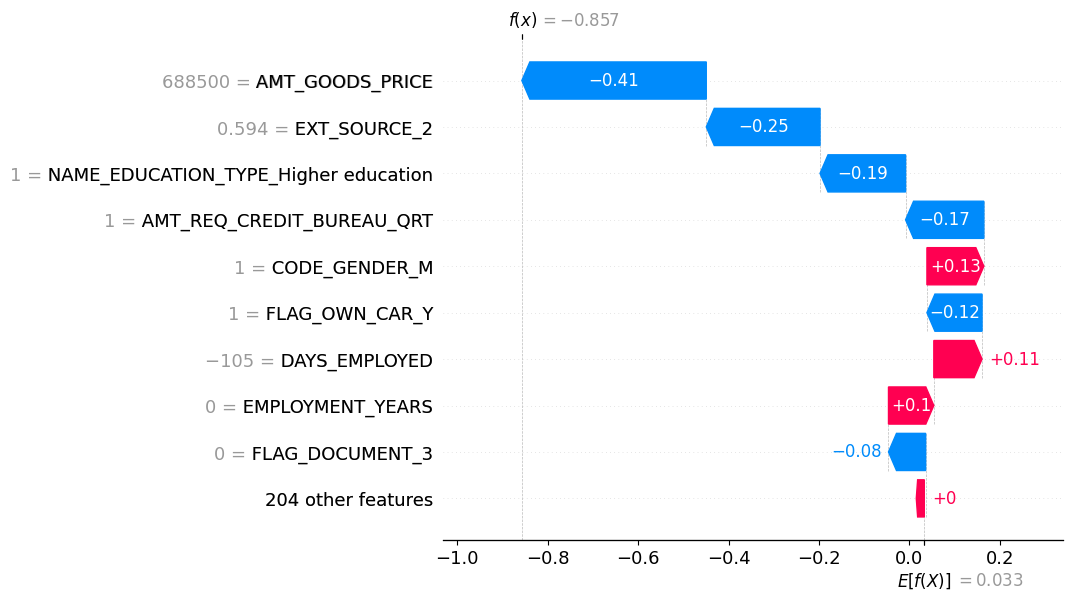

In [11]:
# Generate the explanation:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer],
        base_values=explainer.expected_value,
        data=X_test.iloc[customer],
        feature_names=X_test.columns
    )
)

In [13]:
# This interactive plot shows:
# Red arrows → Increase risk
# Blue arrows → Reduce risk

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

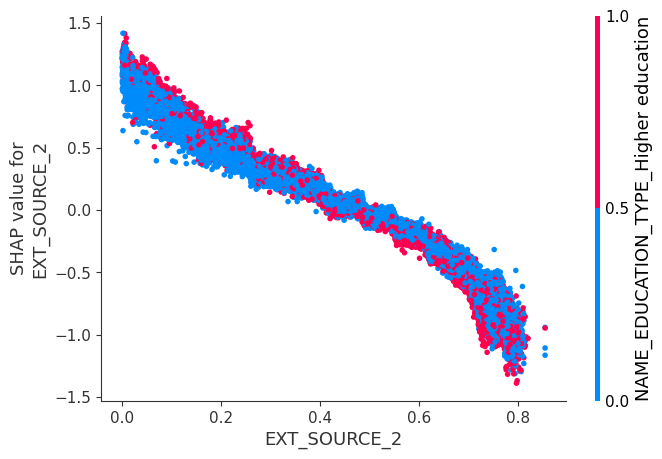

In [14]:
# Dependence Plot
# Let's inspect one important feature.

shap.dependence_plot("EXT_SOURCE_2",shap_values,X_test)